# 00 Data Exploration — NFHS-5 Individual (Stage 1)

Exploratory analysis for the **individual-level** NFHS-5 women's recode (`NFHS5_Individual.csv`, 724,115 rows).

**Analytic sample decision (v5):** model the full 724,115 interviewed women. Barrier items (v467b–h) have zero missingness; some background/household modules are only populated for ~108K women and are encoded with a `missing` category during preprocessing.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Standardized project root discovery
root = Path.cwd().resolve()
while root != root.parent and not (root / 'README.md').exists():
    root = root.parent
PROJECT_ROOT = root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.load_data import BARRIER_SOURCE_COLS, load_stage1_data

RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'NFHS5_Individual.csv'
print('Project root:', PROJECT_ROOT)
print('Raw path:', RAW_PATH)

Project root: C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48
Raw path: C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\data\raw\NFHS5_Individual.csv


In [2]:
df = load_stage1_data()
print('Shape:', df.shape)
print('\nBarrier item missingness:')
for col in BARRIER_SOURCE_COLS:
    if col in df.columns:
        print(col, 'missing:', df[col].isnull().sum())
    else:
        print(col, 'NOT IN FILE')

print('\nBarrier "big problem" rates (individual items):')
for col in ['v467b', 'v467c', 'v467d', 'v467e', 'v467g', 'v467h']:
    if col in df.columns:
        rate = (df[col].astype(str).str.lower().str.strip() == 'big problem').mean()
        print(f'{col}: {rate*100:.1f}%')

from src.preprocessing.target_builder import build_targets
from src.preprocessing.clean import handle_missing

tmp = handle_missing(df.copy())
tmp = build_targets(tmp)

C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\src\preprocessing\load_data.py:120: UserWarning: Columns not found in CSV and skipped: ['v467f', 'v467i', 'm14']
  warnings.warn(f"Columns not found in CSV and skipped: {missing}")


Loaded CSV file: NFHS5_Individual.csv -> (227391, 32)
Analytic sample: full file (227,391 rows)
Shape: (227391, 32)

Barrier item missingness:
v467b missing: 1
v467c missing: 1
v467d missing: 1
v467e missing: 1
v467f NOT IN FILE
v467g missing: 1
v467h missing: 1
v467i NOT IN FILE

Barrier "big problem" rates (individual items):
v467b: 13.7%
v467c: 16.5%
v467d: 22.1%
v467e: 21.6%
v467g: 28.6%
v467h: 37.1%


Dropped v466 (100% missing in this extract)


v131: filled 495 missing values with 'missing'
v717: filled 193365 missing values with 'missing'
v169a: filled 193343 missing values with 'missing'
v170: filled 193343 missing values with 'missing'
v159: filled 1 missing values with 'missing'
v743f: filled 204279 missing values with 'missing'
Feature missing values remaining: 0
target_household: positive rate = 0.2183 (21.8%) | built from ['v467b', 'v467c'] | counts = {0: 177748, 1: 49643}


target_logistic: positive rate = 0.2747 (27.5%) | built from ['v467d', 'v467e'] | counts = {0: 164935, 1: 62456}
target_facility: positive rate = 0.4089 (40.9%) | built from ['v467g', 'v467h'] | counts = {0: 134410, 1: 92981}


C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\src\preprocessing\target_builder.py:28: UserWarning: target_household: missing barrier columns ['v467f']; building from available columns only.
  warnings.warn(
C:\Users\hireg\OneDrive\Desktop\Major project\Major Phase v2\BarrierLens_MP_G25_P48\src\preprocessing\target_builder.py:28: UserWarning: target_facility: missing barrier columns ['v467i']; building from available columns only.
  warnings.warn(


In [3]:
from src.preprocessing.load_data import FEATURE_COLS

df = pd.read_csv(RAW_PATH, low_memory=False)
df.columns = df.columns.str.strip()

print('Shape:', df.shape)
print('First 10 columns:', df.columns[:10].tolist())
print('\nDtypes (top 20):')
print(df.dtypes.head(20))

df.head(3)

Shape: (227391, 32)
First 10 columns: ['caseid', 'v001', 'v002', 'v021', 'v024', 'v025', 'v012', 'v013', 'v106', 'v130']

Dtypes (top 20):
caseid      str
v001      int64
v002      int64
v021      int64
v024        str
v025        str
v012      int64
v013        str
v106        str
v130        str
v131        str
v501        str
v717        str
v190        str
v169a       str
v170        str
v481        str
v157        str
v158        str
v159        str
dtype: object


,caseid,v001,v002,v021,v024,v025,v012,v013,v106,v130,...,v467b,v467c,v467d,v467e,v467g,v467h,v626a,s245a,s245b,s245h
0,0100101305 04,113,5,113,jammu & kashmir,rural,22,20-24,higher,muslim,...,big problem,not a big problem,not a big problem,big problem,big problem,big problem,never had sex,NaN,NaN,NaN
1,0100101305 05,113,5,113,jammu & kashmir,rural,19,15-19,secondary,muslim,...,big problem,big problem,big problem,big problem,big problem,big problem,never had sex,NaN,NaN,NaN
2,0100101345 02,113,45,113,jammu & kashmir,rural,38,35-39,primary,muslim,...,no problem,no problem,no problem,no problem,no problem,no problem,using for limiting,NaN,NaN,NaN


In [4]:
from src.preprocessing.load_data import FEATURE_COLS

feature_missing = pd.Series(
    {col: df[col].isna().mean() * 100 for col in FEATURE_COLS if col in df.columns}
).sort_values(ascending=False)

print('Feature missingness (% of rows):')
feature_missing.head(10)

Feature missingness (% of rows):


v743f    89.836009
v169a    85.026672
v717     85.026672
v170     85.026672
v159      0.000440
v013      0.000000
v012      0.000000
v501      0.000000
v131      0.000000
v130      0.000000
dtype: float64

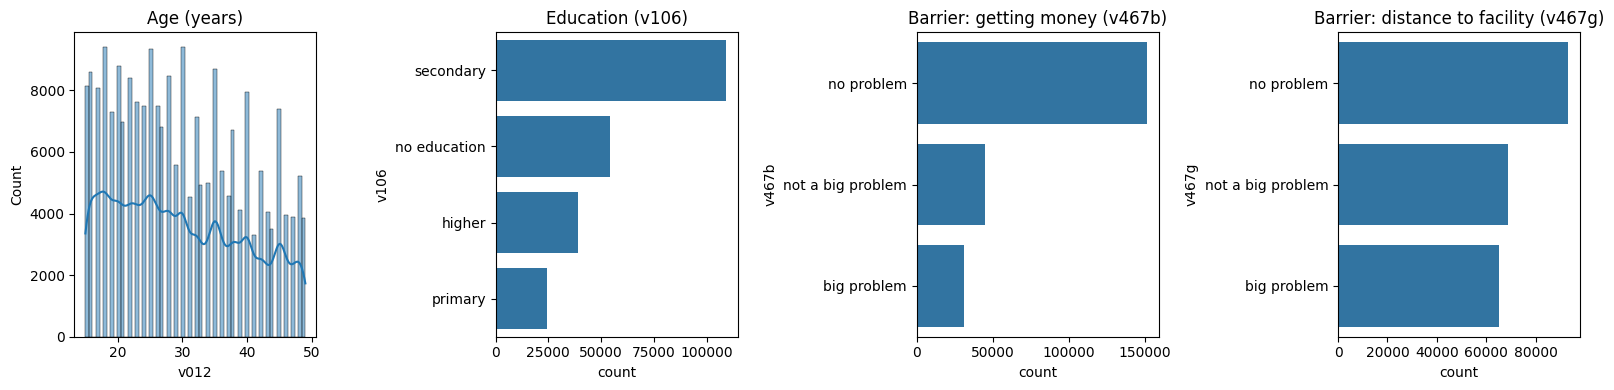

In [5]:
# Individual-level distributions (replaces old district-level indicator histograms)
plot_specs = [
    ('v012', 'Age (years)', 'hist'),
    ('v106', 'Education (v106)', 'count'),
    ('v467b', 'Barrier: getting money (v467b)', 'count'),
    ('v467g', 'Barrier: distance to facility (v467g)', 'count'),
]

available = [(col, title, kind) for col, title, kind in plot_specs if col in df.columns]
if not available:
    print('No plot columns found in dataframe.')
else:
    n = len(available)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, (col, title, kind) in zip(axes, available):
        if kind == 'hist':
            sns.histplot(pd.to_numeric(df[col], errors='coerce').dropna(), kde=True, ax=ax)
        else:
            order = df[col].astype(str).str.strip().value_counts().index
            sns.countplot(y=df[col].astype(str).str.strip(), order=order, ax=ax)
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

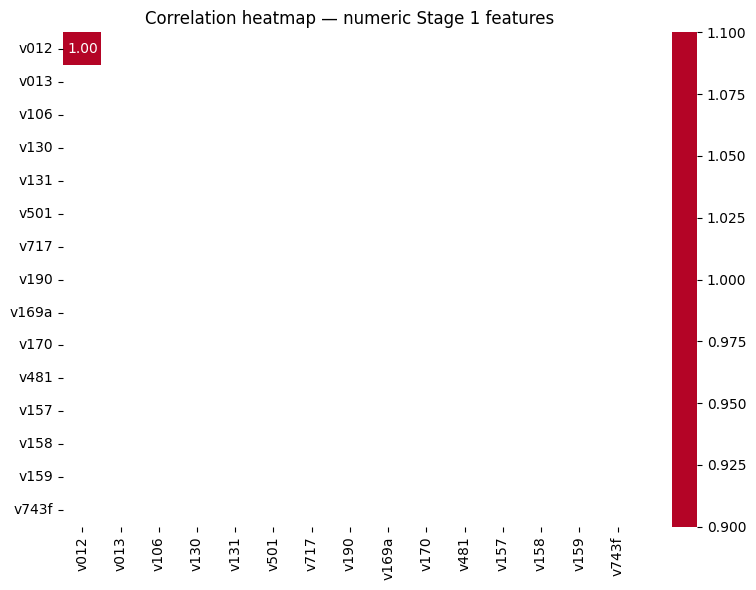

In [6]:
# Correlation among numeric model features (age + media exposure items)
numeric_feature_cols = [
    c for c in FEATURE_COLS
    if c in df.columns and pd.api.types.is_numeric_dtype(pd.to_numeric(df[c], errors='coerce'))
]

numeric_df = df[numeric_feature_cols].apply(pd.to_numeric, errors='coerce')

if numeric_df.shape[1] < 2:
    print('Not enough numeric feature columns for a heatmap.')
else:
    plt.figure(figsize=(8, 6))
    sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Correlation heatmap — numeric Stage 1 features')
    plt.tight_layout()
    plt.show()

In [7]:
import sys
from pathlib import Path
import pandas as pd

DTA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'IAIR7EFL.DTA'
CSV_PATH = PROJECT_ROOT / 'data' / 'raw' / 'NFHS5_Individual.csv'

if DTA_PATH.exists():
    from scripts.patch_m14_extract import read_m14_from_dta
    m14_df = read_m14_from_dta(DTA_PATH)
    existing = pd.read_csv(CSV_PATH, low_memory=False)
    existing.columns = existing.columns.str.strip()
    if 'm14' in existing.columns:
        existing = existing.drop(columns=['m14'])
    merged = existing.merge(m14_df, on='caseid', how='left')
    merged.to_csv(CSV_PATH, index=False)
else:
    print('IAIR7EFL.DTA Stata file not present — using m14 column already present in NFHS5_Individual.csv')
    merged = pd.read_csv(CSV_PATH, low_memory=False)

if 'm14' in merged.columns:
    n_nonnull = merged['m14'].notna().sum()
    print(f'm14 non-null: {n_nonnull:,} / {len(merged):,} ({100 * n_nonnull / len(merged):.1f}%)')


IAIR7EFL.DTA Stata file not present — using m14 column already present in NFHS5_Individual.csv


In [8]:
import sys
from pathlib import Path
import pandas as pd

DTA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'IAIR7EFL.DTA'
CSV_PATH = PROJECT_ROOT / 'data' / 'raw' / 'NFHS5_Individual.csv'

if DTA_PATH.exists():
    from scripts.patch_m14_extract import read_m14_from_dta
    m14_df = read_m14_from_dta(DTA_PATH)
    existing = pd.read_csv(CSV_PATH, low_memory=False)
    existing.columns = existing.columns.str.strip()
    if 'm14' in existing.columns:
        existing = existing.drop(columns=['m14'])
    merged = existing.merge(m14_df, on='caseid', how='left')
    merged.to_csv(CSV_PATH, index=False)
else:
    print('IAIR7EFL.DTA Stata file not present — using m14 column already present in NFHS5_Individual.csv')
    merged = pd.read_csv(CSV_PATH, low_memory=False)

if 'm14' in merged.columns:
    n_nonnull = merged['m14'].notna().sum()
    print(f'm14 non-null: {n_nonnull:,} / {len(merged):,} ({100 * n_nonnull / len(merged):.1f}%)')


IAIR7EFL.DTA Stata file not present — using m14 column already present in NFHS5_Individual.csv
